In [1]:

import pandas as pd
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error


C:\Users\Professor\anaconda3\lib\site-packages\scipy\__init__.py:138: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.24.3)
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion} is required for this version of "


In [2]:
raw_df=pd.read_csv('Train.csv')
display(raw_df)

,impressions,clicks,cost,conversions,ad_type,currency,ID,date,call_type,call_status,start_time,duration,end_time,display_location,impression_share,conversions_calls,headline1_len,headline2_len,ad_description_len
0,142.0,15.0,3393.0,0.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,16.279669,0.0,2.0,5.0,11.0
1,89.0,8.0,1817.0,0.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,16.279669,0.0,2.0,2.0,13.0
2,59.0,8.0,1743.0,0.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,16.279669,0.0,2.0,2.0,10.0
3,78.0,4.0,917.0,0.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,16.279669,0.0,2.0,3.0,13.0
4,20.0,1.0,217.0,0.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,16.279669,0.0,2.0,2.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
289921,NaN,NaN,NaN,NaN,NaN,NaN,ID_65687e2b40ea026fcc662a75,2024-02-03,NaN,NaN,NaN,NaN,NaN,NaN,12.035682,0.0,NaN,NaN,NaN
289922,NaN,NaN,NaN,NaN,NaN,NaN,ID_65687e2b40ea026fcc662a75,2024-02-04,NaN,NaN,NaN,NaN,NaN,NaN,15.711023,0.0,NaN,NaN,NaN
289923,NaN,NaN,NaN,NaN,NaN,NaN,ID_65a7bf329fa4627faf28390c,2024-02-03,NaN,NaN,NaN,NaN,NaN,NaN,15.464425,0.0,NaN,NaN,NaN
289924,NaN,NaN,NaN,NaN,NaN,NaN,ID_65b0f65c7fe62e56c5593d55,2024-02-03,NaN,NaN,NaN,NaN,NaN,NaN,10.016481,0.0,NaN,NaN,NaN


0 0 ID_5da86e71bf5dee4cf5047046
0 1 ID_5ee74f25f865a8154966b412
1 0 ID_600d8eaaf5c7660c0b1f0773
1 1 ID_5f3cdce8c0440e2c5902dd59


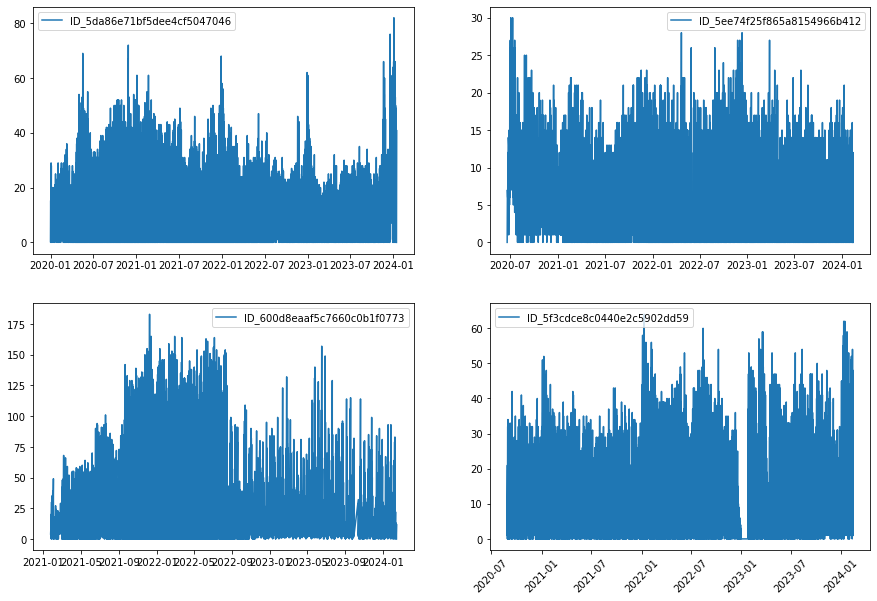

In [3]:
## print(raw_df['ID'].value_counts().index)


raw_df['date']=pd.to_datetime(raw_df['date'],format='%Y-%m-%d')

rows=[0,0,1,1]
cols=[0,1,0,1]
unique_catagories=['ID_5da86e71bf5dee4cf5047046','ID_5ee74f25f865a8154966b412','ID_600d8eaaf5c7660c0b1f0773','ID_5f3cdce8c0440e2c5902dd59']

fig,axes= plt.subplots(2,2,figsize=(15,10))

for row,col, catagory in zip(rows,cols,unique_catagories):
    print(row,col,catagory)

    category_vector= raw_df[raw_df['ID']==catagory]
    axes[row,col].plot(category_vector['date'], category_vector['clicks'], label=catagory)
    axes[row,col].legend()

    plt.xticks(rotation='45')
    
plt.show()

In [4]:
print(raw_df.shape)
#print(pd.DataFrame(raw_df.isnull().sum()))
t=raw_df[raw_df['ID']=='ID_5da86e71bf5dee4cf5047046']['date'].value_counts().index

for date in pd.to_datetime(t):
    print(date)

(289926, 19)
2022-03-15 00:00:00
2021-10-14 00:00:00
2022-04-13 00:00:00
2021-11-17 00:00:00
2022-01-09 00:00:00
2022-01-27 00:00:00
2021-02-08 00:00:00
2021-11-18 00:00:00
2021-04-19 00:00:00
2020-12-11 00:00:00
2021-05-13 00:00:00
2020-12-08 00:00:00
2020-12-07 00:00:00
2021-01-09 00:00:00
2021-01-29 00:00:00
2022-04-16 00:00:00
2021-03-05 00:00:00
2020-11-16 00:00:00
2021-04-20 00:00:00
2021-02-22 00:00:00
2022-01-10 00:00:00
2022-11-02 00:00:00
2023-05-26 00:00:00
2023-11-29 00:00:00
2022-08-07 00:00:00
2021-04-07 00:00:00
2023-07-01 00:00:00
2021-07-08 00:00:00
2022-02-06 00:00:00
2021-12-15 00:00:00
2022-01-23 00:00:00
2021-12-07 00:00:00
2021-08-03 00:00:00
2021-11-09 00:00:00
2022-02-13 00:00:00
2021-09-17 00:00:00
2022-02-15 00:00:00
2021-11-07 00:00:00
2022-01-15 00:00:00
2022-02-17 00:00:00
2021-11-12 00:00:00
2022-01-30 00:00:00
2021-08-13 00:00:00
2021-12-30 00:00:00
2022-01-29 00:00:00
2022-03-14 00:00:00
2022-02-21 00:00:00
2021-08-10 00:00:00
2021-07-19 00:00:00
2022-01

2020-01-01 00:00:00
2020-01-05 00:00:00
2020-01-14 00:00:00
2020-01-15 00:00:00
2020-01-03 00:00:00
2020-01-04 00:00:00
2020-01-11 00:00:00
2020-01-12 00:00:00
2020-01-16 00:00:00
2023-12-16 00:00:00
2020-01-09 00:00:00
2020-01-02 00:00:00
2020-01-06 00:00:00
2020-01-10 00:00:00
2020-02-01 00:00:00
2020-01-08 00:00:00
2023-12-18 00:00:00
2023-12-19 00:00:00
2023-12-17 00:00:00
2023-12-20 00:00:00
2023-12-22 00:00:00
2023-12-21 00:00:00


# Preprocessing:

In [5]:
#Dropping columns with too many null values
raw_df.columns=raw_df.columns.str.strip()
df=raw_df.drop(columns=['call_type','call_status','start_time','duration','end_time','display_location','conversions_calls'],axis=1).copy()

In [6]:

#Dropping rows with null values
columns_with_nan= ['impressions','clicks','cost','conversions','ad_type','currency','headline1_len','headline2_len','ad_description_len']
cleaned_df=df.dropna(subset=columns_with_nan)
display(cleaned_df)

,impressions,clicks,cost,conversions,ad_type,currency,ID,date,impression_share,headline1_len,headline2_len,ad_description_len
0,142.0,15.0,3393.000000,0.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,5.0,11.0
1,89.0,8.0,1817.000000,0.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,2.0,13.0
2,59.0,8.0,1743.000000,0.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,2.0,10.0
3,78.0,4.0,917.000000,0.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,3.0,13.0
4,20.0,1.0,217.000000,0.0,EXPANDED_TEXT_AD,ZAR,ID_5da86e71bf5dee4cf5047046,2020-01-01,16.279669,2.0,2.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...
289521,299.0,29.0,6809.716151,0.0,RESPONSIVE_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.990000,1.0,5.0,13.0
289522,410.0,28.0,6598.474957,0.0,RESPONSIVE_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.990000,1.0,4.0,16.0
289523,281.0,11.0,3642.348176,0.0,RESPONSIVE_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.990000,1.0,4.0,14.0
289524,41.0,5.0,547.477180,0.0,EXPANDED_DYNAMIC_SEARCH_AD,ZAR,ID_65b0f65c7fe62e56c5593d55,2024-02-13,9.990000,0.0,0.0,0.0


In [7]:
print(cleaned_df['ID'].value_counts())

ID_5da86e71bf5dee4cf5047046    15150
ID_5ee74f25f865a8154966b412     9538
ID_600d8eaaf5c7660c0b1f0773     8691
ID_5f3cdce8c0440e2c5902dd59     8657
ID_61321c129a9b4c145436394d     8627
                               ...  
ID_65278bc176ff2b5ae5093c89       75
ID_64be5c51a5db0060046fa166       68
ID_6548ff76c7b54008b66d7797       66
ID_65a7bf329fa4627faf28390c       65
ID_6491a50ce7b72a70aa75437a       49
Name: ID, Length: 185, dtype: int64


In [8]:
print(pd.DataFrame(cleaned_df.isnull().sum()))

                    0
impressions         0
clicks              0
cost                0
conversions         0
ad_type             0
currency            0
ID                  0
date                0
impression_share    0
headline1_len       0
headline2_len       0
ad_description_len  0


In [9]:
print(cleaned_df['ad_type'].value_counts())

EXPANDED_TEXT_AD              148103
RESPONSIVE_SEARCH_AD           96979
EXPANDED_DYNAMIC_SEARCH_AD     44444
Name: ad_type, dtype: int64


# model Training

In [10]:
X=cleaned_df.drop(columns=['clicks','ad_type','currency','ID','date'],axis=1)
y=cleaned_df['clicks']

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2, random_state=42)

model=DecisionTreeRegressor(random_state=42)
model.fit(X_train,y_train)

y_pred=model.predict(X_test)

mse_score=mean_squared_error(y_test,y_pred)

print(mse_score)

52.95527665526888


In [11]:
df2=pd.read_csv('SampleSubmission.csv')
display(df2)


,ID,clicks
0,ID_5da86e71bf5dee4cf5047046_2024_01_22,0
1,ID_5da86e71bf5dee4cf5047046_2024_01_29,0
2,ID_5e43c29e6279884e2827d894_2024_02_21,0
3,ID_5e43c29e6279884e2827d894_2024_02_28,0
4,ID_5e4e7b480e374330ee151305_2023_12_04,0
...,...,...
365,ID_6568807cbb9c4d235c5dd9a8_2024_02_06,0
366,ID_65a7bf329fa4627faf28390c_2024_02_21,0
367,ID_65a7bf329fa4627faf28390c_2024_02_28,0
368,ID_65b0f65c7fe62e56c5593d55_2024_02_21,0


In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

#WE ARE GETTING RID OF REPETITIVE SAME DATES:

# Example time series data with numerical and categorical columns
data = {
    'IDS': ['ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046',
            'ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046',
            'ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046',
            'ID_5da86e71bf5dee4cf5047046','ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412',
            'ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412',
            'ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412',
            'ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412'],
    
    'date': pd.to_datetime(['2022-01-01','2022-01-01','2022-01-02','2022-01-03','2022-01-04',
                            '2022-01-05','2022-01-05','2022-01-06','2022-01-07','2022-01-08',
                            '2022-01-15','2022-01-15','2022-01-16','2022-01-17','2022-01-18',
                            '2022-01-22','2022-01-23','2022-01-24','2022-01-26','2022-01-28']),
    
    'value': [10, 20, 15, 25, 30,11, 21, 16, 26, 31,11, 21, 16, 26, 31,11, 21, 16, 26, 31],
    'category': ['B', 'B', 'A', 'C', 'C','B', 'B', 'A', 'C', 'C','B', 'B', 'A', 'C', 'C','B', 'B', 'A', 'C', 'C']
}

# Convert data to DataFrame
df = pd.DataFrame(data)

# Convert 'date' column to datetime and set as index
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# Ensure unique index values by grouping and aggregating
df = df.groupby(level=0).first()

def custom_resample(column):
    if pd.api.types.is_numeric_dtype(column):
        return column.resample('D').mean()  # Resample numerical columns by taking the mean
    elif pd.api.types.is_categorical_dtype(column):
        return column.resample('D').mode()  # Resample categorical columns by taking the mode
    else:
        return column  # Return unchanged for other column types

# Apply custom resampling function to each column
resampled_data = df.apply(custom_resample)

display(resampled_data)


,IDS,value,category
date,,,
2022-01-01,ID_5da86e71bf5dee4cf5047046,10.0,B
2022-01-02,ID_5da86e71bf5dee4cf5047046,15.0,A
2022-01-03,ID_5da86e71bf5dee4cf5047046,25.0,C
2022-01-04,ID_5da86e71bf5dee4cf5047046,30.0,C
2022-01-05,ID_5da86e71bf5dee4cf5047046,11.0,B
2022-01-06,ID_5da86e71bf5dee4cf5047046,16.0,A
2022-01-07,ID_5da86e71bf5dee4cf5047046,26.0,C
2022-01-08,ID_5da86e71bf5dee4cf5047046,31.0,C
2022-01-09,NaN,NaN,NaN


In [13]:
#CREATING LAG FEATURE COLUMNS
lag_features_count=2
lag_feature_names=['value','category']
for i in range(1,lag_features_count+1):
    num=str(i)
    resampled_data[f'lag_{num}']=df['value'].shift(i)
    lag_feature_names.append(str(f'lag_{num}'))
display(resampled_data)
print(lag_feature_names)

,IDS,value,category,lag_1,lag_2
date,,,,,
2022-01-01,ID_5da86e71bf5dee4cf5047046,10.0,B,NaN,NaN
2022-01-02,ID_5da86e71bf5dee4cf5047046,15.0,A,10.0,NaN
2022-01-03,ID_5da86e71bf5dee4cf5047046,25.0,C,15.0,10.0
2022-01-04,ID_5da86e71bf5dee4cf5047046,30.0,C,25.0,15.0
2022-01-05,ID_5da86e71bf5dee4cf5047046,11.0,B,30.0,25.0
2022-01-06,ID_5da86e71bf5dee4cf5047046,16.0,A,11.0,30.0
2022-01-07,ID_5da86e71bf5dee4cf5047046,26.0,C,16.0,11.0
2022-01-08,ID_5da86e71bf5dee4cf5047046,31.0,C,26.0,16.0
2022-01-09,NaN,NaN,NaN,NaN,NaN


['value', 'category', 'lag_1', 'lag_2']


In [14]:
columns_with_nan= lag_feature_names
resampled_data= resampled_data.dropna(subset=columns_with_nan)

In [15]:
display(resampled_data)


,IDS,value,category,lag_1,lag_2
date,,,,,
2022-01-03,ID_5da86e71bf5dee4cf5047046,25.0,C,15.0,10.0
2022-01-04,ID_5da86e71bf5dee4cf5047046,30.0,C,25.0,15.0
2022-01-05,ID_5da86e71bf5dee4cf5047046,11.0,B,30.0,25.0
2022-01-06,ID_5da86e71bf5dee4cf5047046,16.0,A,11.0,30.0
2022-01-07,ID_5da86e71bf5dee4cf5047046,26.0,C,16.0,11.0
2022-01-08,ID_5da86e71bf5dee4cf5047046,31.0,C,26.0,16.0
2022-01-15,ID_5ee74f25f865a8154966b412,11.0,B,31.0,26.0
2022-01-16,ID_5ee74f25f865a8154966b412,16.0,A,11.0,31.0
2022-01-17,ID_5ee74f25f865a8154966b412,26.0,C,16.0,11.0


In [16]:
values=list(resampled_data['value'])
print(values)

[25.0, 30.0, 11.0, 16.0, 26.0, 31.0, 11.0, 16.0, 26.0, 31.0, 11.0, 21.0, 16.0, 26.0, 31.0]


In [17]:
print(values[-2])

26.0


In [18]:
#predict lag Features
predict_lag_cols= lag_feature_names[2: len(lag_feature_names)]

print(lag_feature_names[2: len(lag_feature_names)])


max_date=resampled_data.index.max()
print(max_date)

next_date= max_date + pd.Timedelta(days=1)
print(next_date)

predict_features={'date': [next_date],'category':[resampled_data[resampled_data.index >= resampled_data.index.max()-pd.DateOffset(days=7)]['category'].mode().iloc[0]]}

for i, col in enumerate(predict_lag_cols):
    
    predict_features[col]= [values[-(i+1)]]
    

print(predict_features)

pred_df=pd.DataFrame(predict_features)

display(pred_df)



['lag_1', 'lag_2']
2022-01-28 00:00:00
2022-01-29 00:00:00
{'date': [Timestamp('2022-01-29 00:00:00')], 'category': ['B'], 'lag_1': [31.0], 'lag_2': [26.0]}


,date,category,lag_1,lag_2
0,2022-01-29,B,31.0,26.0


In [19]:
p=resampled_data[resampled_data.index >= resampled_data.index.max()-pd.DateOffset(days=6)]['category'].mode().iloc[0]
print(p)

print(resampled_data.index >= resampled_data.index.max()-pd.DateOffset(days=6))

B
[False False False False False False False False False False  True  True
  True  True  True]


In [20]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error

#WE ARE GETTING RID OF REPETITIVE SAME DATES:

# Example time series data with numerical and categorical columns
data = {
    'ID': ['ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046',
            'ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046',
            'ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046',
            'ID_5da86e71bf5dee4cf5047046','ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412',
            'ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412',
            'ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412',
            'ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412'],
    
    'date': ['2022-01-01','2022-01-01','2022-01-02','2022-01-03','2022-01-04',
            '2022-01-05','2022-01-05','2022-01-06','2022-01-07','2022-01-08',
            '2022-01-15','2022-01-15','2022-01-16','2022-01-17','2022-01-18',
            '2022-01-22','2022-01-23','2022-01-24','2022-01-26','2022-01-28'],
    
    'value': [10, 20, 15, 25, 30,11, 21, 16, 26, 31,11, 21, 16, 26, 10,11, 21,58, 27, 33],
    'category': ['B', 'B', 'A', 'C', 'C','B', 'B', 'A', 'C', 'C','D', 'D', 'E', 'C', 'C','B', 'B', 'A', 'D', 'B']
}


# Convert data to DataFrame
df = pd.DataFrame(data)


unique_ids = df['ID'].unique()

column_names=df.columns

id_dictionary={}

count=1

for id in unique_ids:
   
    for col in column_names:
        id_dictionary[col]= list(df[df['ID']==id][col])  #inserting column observations belonging to a specific ID

    id_df=pd.DataFrame(id_dictionary)


    # Convert 'date' column to datetime and set as index
    id_df['date'] = pd.to_datetime(id_df['date'])
    
    #setting date as index
    id_df.set_index('date', inplace=True)

    # Ensure unique index values by grouping and aggregating
    id_df = id_df.groupby(level=0).first()

    def custom_resample(column):
        if pd.api.types.is_numeric_dtype(column):
            return column.resample('D').mean()  # Resample numerical columns by taking the mean
        elif pd.api.types.is_categorical_dtype(column):
            return column.resample('D').mode()  # Resample categorical columns by mode filling
        else:
            return column  # Return unchanged for other column types

    # Apply custom resampling function to each column
    resampled_raw_data = id_df.apply(custom_resample)
    
    display(resampled_raw_data)

    resampled_data= resampled_raw_data.copy()

    ##############################################################################################
    print("#"*74)

    #CREATING LAG FEATURE COLUMNS
    lag_features_count=2
    lag_feature_names=['value','category']
    for i in range(1,lag_features_count+1):
        num=str(i)
        resampled_data[f'lag_{num}']=id_df['value'].shift(i)
        lag_feature_names.append(str(f'lag_{num}'))
   
    

    ##############################################################################################
    print("#"*74)

    columns_with_nan= lag_feature_names
    resampled_data= resampled_data.dropna(subset=columns_with_nan)

    display(resampled_data)

    ##############################################################################################
    print("#"*74)

    values=list(resampled_data['value'])
   


    ##############################################################################################
    print("#"*74)

    #predict lag Features
    predict_lag_cols= lag_feature_names[2: len(lag_feature_names)]

    max_date=resampled_data.index.max()
    print(max_date)

    next_date= max_date + pd.Timedelta(days=1)
   

    predict_features={'date': [next_date], 
                      'ID':[id],
                      'category':[resampled_data[resampled_data.index >= resampled_data.index.max()-pd.DateOffset(days=3)]['category'].mode().iloc[0]]}

    count=count+1
    
    
    
    for i, colu in enumerate(predict_lag_cols):

        predict_features[colu]= [values[-(i+1)]]


   
    pred_df=pd.DataFrame(predict_features)
    
     # Convert 'date' column to datetime and set as index
    pred_df['date'] = pd.to_datetime(pred_df['date'])
    
    #setting date as index
    pred_df.set_index('date', inplace=True)

    display(pred_df)
    
    ##################################################################################################
    
    
    X=resampled_data.drop(columns=['value','ID','category'],axis=1)
    y=resampled_data['value']

    X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.1, random_state=42)

    model=DecisionTreeRegressor(random_state=42)
    model.fit(X_train,y_train)

    y_pred=model.predict(X_test)

    mse_score=mean_squared_error(y_test,y_pred)

    print(mse_score)
    
    X_pred =pred_df.drop(columns=['ID','category'],axis=1)
    new_y_pred=model.predict(X_pred)
    print(new_y_pred)
    
    predict_features=pd.DataFrame({'date': [next_date], 
                      'ID':[id],
                      'value': new_y_pred,
                      'category':[resampled_data[resampled_data.index >= resampled_data.index.max()-pd.DateOffset(days=3)]['category'].mode().iloc[0]]})

    predict_features=pd.DataFrame(predict_features)
    
    df=pd.concat([df,predict_features],axis=0)
    
    display(df)
    
    

,ID,value,category
date,,,
2022-01-01,ID_5da86e71bf5dee4cf5047046,10,B
2022-01-02,ID_5da86e71bf5dee4cf5047046,15,A
2022-01-03,ID_5da86e71bf5dee4cf5047046,25,C
2022-01-04,ID_5da86e71bf5dee4cf5047046,30,C
2022-01-05,ID_5da86e71bf5dee4cf5047046,11,B
2022-01-06,ID_5da86e71bf5dee4cf5047046,16,A
2022-01-07,ID_5da86e71bf5dee4cf5047046,26,C
2022-01-08,ID_5da86e71bf5dee4cf5047046,31,C


##########################################################################
##########################################################################


,ID,value,category,lag_1,lag_2
date,,,,,
2022-01-03,ID_5da86e71bf5dee4cf5047046,25,C,15.0,10.0
2022-01-04,ID_5da86e71bf5dee4cf5047046,30,C,25.0,15.0
2022-01-05,ID_5da86e71bf5dee4cf5047046,11,B,30.0,25.0
2022-01-06,ID_5da86e71bf5dee4cf5047046,16,A,11.0,30.0
2022-01-07,ID_5da86e71bf5dee4cf5047046,26,C,16.0,11.0
2022-01-08,ID_5da86e71bf5dee4cf5047046,31,C,26.0,16.0


##########################################################################
##########################################################################
2022-01-08 00:00:00


,ID,category,lag_1,lag_2
date,,,,
2022-01-09,ID_5da86e71bf5dee4cf5047046,C,31,26


...

,ID,value,category,lag_1,lag_2
date,,,,,
2022-01-17,ID_5ee74f25f865a8154966b412,26.0,C,16.0,11.0
2022-01-18,ID_5ee74f25f865a8154966b412,10.0,C,26.0,16.0
2022-01-22,ID_5ee74f25f865a8154966b412,11.0,B,10.0,26.0
2022-01-23,ID_5ee74f25f865a8154966b412,21.0,B,11.0,10.0
2022-01-24,ID_5ee74f25f865a8154966b412,58.0,A,21.0,11.0
2022-01-26,ID_5ee74f25f865a8154966b412,27.0,D,58.0,21.0
2022-01-28,ID_5ee74f25f865a8154966b412,33.0,B,27.0,58.0


##########################################################################
##########################################################################
2022-01-28 00:00:00


,ID,category,lag_1,lag_2
date,,,,
2022-01-29,ID_5ee74f25f865a8154966b412,B,33.0,27.0


1024.0
[27.]


,ID,date,value,category
0,ID_5da86e71bf5dee4cf5047046,2022-01-01,10.0,B
1,ID_5da86e71bf5dee4cf5047046,2022-01-01,20.0,B
2,ID_5da86e71bf5dee4cf5047046,2022-01-02,15.0,A
3,ID_5da86e71bf5dee4cf5047046,2022-01-03,25.0,C
4,ID_5da86e71bf5dee4cf5047046,2022-01-04,30.0,C
5,ID_5da86e71bf5dee4cf5047046,2022-01-05,11.0,B
6,ID_5da86e71bf5dee4cf5047046,2022-01-05,21.0,B
7,ID_5da86e71bf5dee4cf5047046,2022-01-06,16.0,A
8,ID_5da86e71bf5dee4cf5047046,2022-01-07,26.0,C
9,ID_5da86e71bf5dee4cf5047046,2022-01-08,31.0,C


In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error


def TimeSeries(days):

    #WE ARE GETTING RID OF REPETITIVE SAME DATES:

    # Example time series data with numerical and categorical columns
    data = {
        'ID': ['ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046',
                'ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046',
                'ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046',
                'ID_5da86e71bf5dee4cf5047046','ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412',
                'ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412',
                'ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412',
                'ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412'],

        'date': ['2022-01-01','2022-01-01','2022-01-02','2022-01-03','2022-01-04',
                '2022-01-05','2022-01-05','2022-01-06','2022-01-07','2022-01-08',
                '2022-01-15','2022-01-15','2022-01-16','2022-01-17','2022-01-18',
                '2022-01-22','2022-01-23','2022-01-24','2022-01-26','2022-01-28'],

        'value': [10, 20, 51, 25, 70,11, 21, 16, 26, 31,11, 21, 106, 26, 10,11, 271,58, 27, 33],
        'category': ['B', 'B', 'A', 'C', 'C','B', 'B', 'A', 'C', 'C','D', 'D', 'E', 'C', 'C','B', 'B', 'A', 'D', 'B']
    }


    # Convert data to DataFrame
    df = pd.DataFrame(data)


    unique_ids = df['ID'].unique()

    column_names=df.columns

    id_dictionary={}

    count=1
    
    result_df= pd.DataFrame(columns=column_names)
    sorted_df= []
    
    days_count=1
    
    
    for day in range(1, days+1):
        
        for id in unique_ids:
   
            for col in column_names:
                id_dictionary[col]= list(df[df['ID']==id][col])  #inserting column observations belonging to a specific ID

            id_df=pd.DataFrame(id_dictionary)


            # Convert 'date' column to datetime and set as index
            id_df['date'] = pd.to_datetime(id_df['date'])

            #setting date as index
            id_df.set_index('date', inplace=True)

            # Ensure unique index values by grouping and aggregating
            id_df = id_df.groupby(level=0).first()

            def custom_resample(column):
                if pd.api.types.is_numeric_dtype(column):
                    return column.resample('D').mean()  # Resample numerical columns by taking the mean
                elif pd.api.types.is_categorical_dtype(column):
                    return column.resample('D').mode()  # Resample categorical columns by mode filling
                else:
                    return column  # Return unchanged for other column types

            # Apply custom resampling function to each column
            resampled_raw_data = id_df.apply(custom_resample)

        

            resampled_data= resampled_raw_data.copy()
            
            ##############################################################################################
            print("#"*74)

            #CREATING LAG FEATURE COLUMNS
            lag_features_count=2
            lag_feature_names=[]
            all_features=['value','category']
            for i in range(1,lag_features_count+1):
                num=str(i)
                resampled_data[f'lag_{num}']=id_df['value'].shift(i)
                lag_feature_names.append(str(f'lag_{num}'))
                all_features.append(str(f'lag_{num}'))



            ##############################################################################################
            print("#"*74)

            columns_with_nan= lag_feature_names
            resampled_data= resampled_data.dropna(subset=columns_with_nan)


            ##############################################################################################
            print("#"*74)

            values=list(resampled_data['value'])



            ##############################################################################################
            print("#"*74)

            #predict lag Features
            predict_lag_cols= lag_feature_names.copy()
            
            
            max_date=resampled_data.index.max()
            

            next_date= max_date + pd.Timedelta(days=1)


            predict_features={'date': [next_date], 
                              'ID':[id],
                              'category':[resampled_data[resampled_data.index >= resampled_data.index.max()-pd.DateOffset(days=3)]['category'].mode().iloc[0]]}

            count=count+1



            for i, colu in enumerate(predict_lag_cols):

                predict_features[colu]= [values[-(i+1)]]



            pred_df=pd.DataFrame(predict_features)
            
            display(pred_df)

             # Convert 'date' column to datetime and set as index
            pred_df['date'] = pd.to_datetime(pred_df['date'])

            #setting date as index
            pred_df.set_index('date', inplace=True)
           
            
            
            
            ##################################################################################################


            X=resampled_data.drop(columns=['value','ID','category'],axis=1)
            y=resampled_data['value']
            

            X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.1, random_state=42)

            model=DecisionTreeRegressor(random_state=42)
            model.fit(X_train,y_train)

            y_pred=model.predict(X_test)

            mse_score=mean_squared_error(y_test,y_pred)

            print(mse_score)

            X_pred =pred_df.drop(columns=['ID','category'],axis=1)
            new_y_pred=model.predict(X_pred)
           

            predict_features=pd.DataFrame({'date': [next_date], 
                              'ID':[id],
                              'value': new_y_pred,
                              'category':[resampled_data[resampled_data.index >= resampled_data.index.max()-pd.DateOffset(13)]['category'].mode().iloc[0]]})

            predict_features=pd.DataFrame(predict_features)

            df=pd.concat([df,predict_features],axis=0)
            
            
            #All features
            all_predict_features=pd.DataFrame({'date': [next_date], 
            'ID':[id],
            'value': new_y_pred,
            'category':[resampled_data[resampled_data.index >= resampled_data.index.max()-pd.DateOffset(13)]['category'].mode().iloc[0]]})

            for i, colu in enumerate(predict_lag_cols):

                all_predict_features[colu]= [values[-(i+1)]]


            if days_count==7 or days_count==14:
                result_df=result_df.append(all_predict_features,ignore_index=True)
                
            
            
            
        days_count= days_count+1
        
        
            
    return result_df


outcome=TimeSeries(14)
dic=[]
#display(outcome)

records_dic=outcome.to_dict(orient='records')
list_dic=outcome.to_dict(orient='list')

print(records_dic)

print('\n')
print(list_dic)

for id in unique_ids:
    for row in records_dic:
    
        if row['ID']==id:
            dic.append(row)
            
print('\n')
display(pd.DataFrame(dic))

##########################################################################
##########################################################################
##########################################################################
##########################################################################


,date,ID,category,lag_1,lag_2
0,2022-01-09,ID_5da86e71bf5dee4cf5047046,C,31,26


1.0
##########################################################################
##########################################################################
##########################################################################
##########################################################################


,date,ID,category,lag_1,lag_2
0,2022-01-29,ID_5ee74f25f865a8154966b412,B,33.0,27.0


1024.0
##########################################################################
##########################################################################
##########################################################################
##########################################################################


...

,date,ID,category,lag_1,lag_2
0,2022-01-22,ID_5da86e71bf5dee4cf5047046,C,11.0,11.0


13.0
##########################################################################
##########################################################################
##########################################################################
##########################################################################


,date,ID,category,lag_1,lag_2
0,2022-02-11,ID_5ee74f25f865a8154966b412,B,33.0,33.0


24.5
[{'ID': 'ID_5da86e71bf5dee4cf5047046', 'date': Timestamp('2022-01-15 00:00:00'), 'value': 26.0, 'category': 'C', 'lag_1': 26.0, 'lag_2': 11.0}, {'ID': 'ID_5ee74f25f865a8154966b412', 'date': Timestamp('2022-02-04 00:00:00'), 'value': 33.0, 'category': 'B', 'lag_1': 33.0, 'lag_2': 33.0}, {'ID': 'ID_5da86e71bf5dee4cf5047046', 'date': Timestamp('2022-01-22 00:00:00'), 'value': 26.0, 'category': 'C', 'lag_1': 11.0, 'lag_2': 11.0}, {'ID': 'ID_5ee74f25f865a8154966b412', 'date': Timestamp('2022-02-11 00:00:00'), 'value': 33.0, 'category': 'B', 'lag_1': 33.0, 'lag_2': 33.0}]


{'ID': ['ID_5da86e71bf5dee4cf5047046', 'ID_5ee74f25f865a8154966b412', 'ID_5da86e71bf5dee4cf5047046', 'ID_5ee74f25f865a8154966b412'], 'date': [Timestamp('2022-01-15 00:00:00'), Timestamp('2022-02-04 00:00:00'), Timestamp('2022-01-22 00:00:00'), Timestamp('2022-02-11 00:00:00')], 'value': [26.0, 33.0, 26.0, 33.0], 'category': ['C', 'B', 'C', 'B'], 'lag_1': [26.0, 33.0, 11.0, 33.0], 'lag_2': [11.0, 33.0, 11.0, 33.0]}




,ID,date,value,category,lag_1,lag_2
0,ID_5da86e71bf5dee4cf5047046,2022-01-15,26.0,C,26.0,11.0
1,ID_5da86e71bf5dee4cf5047046,2022-01-22,26.0,C,11.0,11.0
2,ID_5ee74f25f865a8154966b412,2022-02-04,33.0,B,33.0,33.0
3,ID_5ee74f25f865a8154966b412,2022-02-11,33.0,B,33.0,33.0


In [22]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder



def TimeSeries(days):

    #WE ARE GETTING RID OF REPETITIVE SAME DATES:

    # Example time series data with numerical and categorical columns
    data = {
        'ID': ['ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046',
                'ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046',
                'ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046',
                'ID_5da86e71bf5dee4cf5047046','ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412',
                'ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412',
                'ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412',
                'ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412'],

        'date': ['2022-01-01','2022-01-01','2022-01-02','2022-01-03','2022-01-04',
                '2022-01-05','2022-01-05','2022-01-06','2022-01-07','2022-01-08',
                '2022-01-15','2022-01-15','2022-01-16','2022-01-17','2022-01-18',
                '2022-01-22','2022-01-23','2022-01-24','2022-01-26','2022-01-28'],

        'value': [10, 20, 51, 25, 70,11, 21, 16, 26, 31,11, 21, 106, 26, 10,11, 271,58, 27, 33],
        'category': ['B', 'B', 'A', 'C', 'C','B', 'B', 'A', 'C', 'C','D', 'D', 'E', 'C', 'C','B', 'B', 'A', 'D', 'B']
    }


    # Convert data to DataFrame
    df = pd.DataFrame(data)
    
    # Encoding different columns (With label encoder)
    label_enc=['category']
    label_encoder = LabelEncoder()
    
    for column in label_enc:
        encoded_value= label_encoder.fit_transform(df[column])
        df[column]= encoded_value


    unique_ids = df['ID'].unique()

    column_names=df.columns
    
    id_dictionary={}

    count=1
    
    result_df= pd.DataFrame(columns=column_names)
    sorted_df= []
    
    days_count=1
    
    
    for day in range(1, days+1):
        
        for id in unique_ids:
   
            for col in column_names:
                id_dictionary[col]= list(df[df['ID']==id][col])  #inserting column observations belonging to a specific ID

            id_df=pd.DataFrame(id_dictionary)


            # Convert 'date' column to datetime and set as index
            id_df['date'] = pd.to_datetime(id_df['date'])

            #setting date as index
            id_df.set_index('date', inplace=True)

            # Ensure unique index values by grouping and aggregating
            id_df = id_df.groupby(level=0).first()

            def custom_resample(column):
                if pd.api.types.is_numeric_dtype(column):
                    return column.resample('D').mean()  # Resample numerical columns by taking the mean
                elif pd.api.types.is_categorical_dtype(column):
                    return column.resample('D').mode()  # Resample categorical columns by mode filling
                else:
                    return column  # Return unchanged for other column types

            # Apply custom resampling function to each column
            resampled_raw_data = id_df.apply(custom_resample)

        

            resampled_data= resampled_raw_data.copy()
            
            ##############################################################################################
            print("#"*74)

            #CREATING LAG FEATURE COLUMNS
            lag_features_count=4
            lag_feature_names=[]
            all_features=[]
            
            for name in column_names:
                all_features.append(name)
                
            for i in range(1,lag_features_count+1):
                num=str(i)
                resampled_data[f'lag_{num}']=id_df['value'].shift(i)
                lag_feature_names.append(str(f'lag_{num}'))
                all_features.append(str(f'lag_{num}'))

            
            ##############################################################################################
            print("#"*74)

            columns_with_nan= lag_feature_names
            resampled_data= resampled_data.dropna(subset=columns_with_nan)


            ##############################################################################################
            print("#"*74)

            values=list(resampled_data['value'])



            ##############################################################################################
            print("#"*74)

            #predict lag Features
            predict_lag_cols= lag_feature_names.copy()
            
            
            max_date=resampled_data.index.max()
            

            next_date= max_date + pd.Timedelta(days=1)


            predict_features={'date': [next_date], 
                              'ID':[id],
                              'category':[resampled_data[resampled_data.index >= resampled_data.index.max()-pd.DateOffset(days=3)]['category'].mode().iloc[0]]}

            count=count+1



            for i, colu in enumerate(predict_lag_cols):

                predict_features[colu]= [values[-(i+1)]]



            pred_df=pd.DataFrame(predict_features)
            
            

             # Convert 'date' column to datetime and set as index
            pred_df['date'] = pd.to_datetime(pred_df['date'])

            #setting date as index
            pred_df.set_index('date', inplace=True)
           
            
            
            
            ##################################################################################################


            X=resampled_data.drop(columns=['value','ID'],axis=1)
            y=resampled_data['value']
            

            X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.1, random_state=42)

            model=DecisionTreeRegressor(random_state=42)
            model.fit(X_train,y_train)

            y_pred=model.predict(X_test)

            mse_score=mean_squared_error(y_test,y_pred)

            print(mse_score)

            X_pred =pred_df.drop(columns=['ID'],axis=1)
            display(X_pred)
            new_y_pred=model.predict(X_pred)
           

            predict_features=pd.DataFrame({'date': [next_date], 
                              'ID':[id],
                              'value': new_y_pred,
                              'category':[resampled_data[resampled_data.index >= resampled_data.index.max()-pd.DateOffset(13)]['category'].mode().iloc[0]]})

            predict_features=pd.DataFrame(predict_features)

            df=pd.concat([df,predict_features],axis=0)
            
            
            #All features
            all_predict_features=pd.DataFrame({'date': [next_date], 
            'ID':[id],
            'value': new_y_pred,
            'category':[resampled_data[resampled_data.index >= resampled_data.index.max()-pd.DateOffset(13)]['category'].mode().iloc[0]]})

            for i, colu in enumerate(predict_lag_cols):

                all_predict_features[colu]= [values[-(i+1)]]


            if days_count==7 or days_count==14:
                result_df=result_df.append(all_predict_features,ignore_index=True)
                
            
            
            
        days_count= days_count+1
        
        
            
    return result_df


outcome=TimeSeries(14)
dic=[]
#display(outcome)

records_dic=outcome.to_dict(orient='records')
list_dic=outcome.to_dict(orient='list')



print('\n')


for id in unique_ids:
    for row in records_dic:
    
        if row['ID']==id:
            dic.append(row)
            
print('\n')
display(pd.DataFrame(dic))

##########################################################################
##########################################################################
##########################################################################
##########################################################################
100.0


,category,lag_1,lag_2,lag_3,lag_4
date,,,,,
2022-01-09,2,31,26,16,11


##########################################################################
##########################################################################
##########################################################################
##########################################################################
67600.0


,category,lag_1,lag_2,lag_3,lag_4
date,,,,,
2022-01-29,1.0,33.0,27.0,58.0,271.0


##########################################################################
##########################################################################
##########################################################################
##########################################################################
100.0


...

##########################################################################
##########################################################################
##########################################################################
##########################################################################
225.0


,category,lag_1,lag_2,lag_3,lag_4
date,,,,,
2022-01-22,2.0,31.0,31.0,31.0,31.0


##########################################################################
##########################################################################
##########################################################################
##########################################################################
28564.0


,category,lag_1,lag_2,lag_3,lag_4
date,,,,,
2022-02-11,1.0,33.0,33.0,33.0,33.0


,ID,date,value,category,lag_1,lag_2,lag_3,lag_4
0,ID_5da86e71bf5dee4cf5047046,2022-01-15,31.0,2.0,31.0,31.0,31.0,31.0
1,ID_5da86e71bf5dee4cf5047046,2022-01-22,31.0,2.0,31.0,31.0,31.0,31.0
2,ID_5ee74f25f865a8154966b412,2022-02-04,33.0,1.0,33.0,33.0,33.0,33.0
3,ID_5ee74f25f865a8154966b412,2022-02-11,33.0,1.0,33.0,33.0,33.0,33.0


In [23]:
import tensorflow as tf

C:\Users\Professor\anaconda3\lib\site-packages\tensorflow\python\framework\dtypes.py:513: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  np.object,


AttributeError: module 'numpy' has no attribute 'object'.
`np.object` was a deprecated alias for the builtin `object`. To avoid this error in existing code, use `object` by itself. Doing this will not modify any behavior and is safe. 
The aliases was originally deprecated in NumPy 1.20; for more details and guidance see the original release note at:
    https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations

In [ ]:
!python --version

In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense






def TimeSeries(days):

    #WE ARE GETTING RID OF REPETITIVE SAME DATES:

    # Example time series data with numerical and categorical columns
    data = {
        'ID': ['ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046',
                'ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046',
                'ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046',
                'ID_5da86e71bf5dee4cf5047046','ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412',
                'ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412',
                'ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412',
                'ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412'],

        'date': ['2022-01-01','2022-01-01','2022-01-02','2022-01-03','2022-01-04',
                '2022-01-05','2022-01-05','2022-01-06','2022-01-07','2022-01-08',
                '2022-01-15','2022-01-15','2022-01-16','2022-01-17','2022-01-18',
                '2022-01-22','2022-01-23','2022-01-24','2022-01-26','2022-01-28'],

        'value': [10, 20, 51, 25, 70,11, 21, 16, 26, 31,11, 21, 106, 26, 10,11, 271,58, 27, 33],
        'category': ['B', 'B', 'A', 'C', 'C','B', 'B', 'A', 'C', 'C','D', 'D', 'E', 'C', 'C','B', 'B', 'A', 'D', 'B']
    }


    # Convert data to DataFrame
    df = pd.DataFrame(data)
    
    # Encoding different columns (With label encoder)
    label_enc=['category']
    label_encoder = LabelEncoder()
    
    for column in label_enc:
        encoded_value= label_encoder.fit_transform(df[column])
        df[column]= encoded_value


    unique_ids = set(df['ID'])

    column_names=df.columns
    
    id_dictionary={}

    count=1
    
    result_df= pd.DataFrame(columns=column_names)
    sorted_df= []
    
    days_count=1
    
    
    for day in range(1, days+1):
        
        for id in unique_ids:
   
            for col in column_names:
                id_dictionary[col]= list(df[df['ID']==id][col])  #inserting column observations belonging to a specific ID

            id_df=pd.DataFrame(id_dictionary)


            # Convert 'date' column to datetime and set as index
            id_df['date'] = pd.to_datetime(id_df['date'])

            #setting date as index
            id_df.set_index('date', inplace=True)

            # Ensure unique index values by grouping and aggregating
            id_df = id_df.groupby(level=0).first()

            def custom_resample(column):
                if pd.api.types.is_numeric_dtype(column):
                    return column.resample('D').mean()  # Resample numerical columns by taking the mean
                elif pd.api.types.is_categorical_dtype(column):
                    return column.resample('D').mode()  # Resample categorical columns by mode filling
                else:
                    return column  # Return unchanged for other column types

            # Apply custom resampling function to each column
            resampled_raw_data = id_df.apply(custom_resample)

        

            resampled_data= resampled_raw_data.copy()
            
            ##############################################################################################
            print("#"*74)

            #CREATING LAG FEATURE COLUMNS
            lag_features_count=4
            lag_feature_names=[]
            all_features=[]
            
            for name in column_names:
                all_features.append(name)
                
            for i in range(1,lag_features_count+1):
                num=str(i)
                resampled_data[f'lag_{num}']=id_df['value'].shift(i)
                lag_feature_names.append(str(f'lag_{num}'))
                all_features.append(str(f'lag_{num}'))

            
            ##############################################################################################
            print("#"*74)

            columns_with_nan= lag_feature_names
            resampled_data= resampled_data.dropna(subset=columns_with_nan)


            ##############################################################################################
            print("#"*74)

            values=list(resampled_data['value'])



            ##############################################################################################
            print("#"*74)

            #predict lag Features
            predict_lag_cols= lag_feature_names.copy()
            
            
            max_date=resampled_data.index.max()
            

            next_date= max_date + pd.Timedelta(days=1)


            predict_features={'date': [next_date], 
                              'ID':[id],
                              'category':[resampled_data[resampled_data.index >= resampled_data.index.max()-pd.DateOffset(days=3)]['category'].mode().iloc[0]]}

            count=count+1



            for i, colu in enumerate(predict_lag_cols):

                predict_features[colu]= [values[-(i+1)]]



            pred_df=pd.DataFrame(predict_features)
            
            

             # Convert 'date' column to datetime and set as index
            pred_df['date'] = pd.to_datetime(pred_df['date'])

            #setting date as index
            pred_df.set_index('date', inplace=True)
           
            
            
            
            ##################################################################################################


            X=resampled_data.drop(columns=['value','ID'],axis=1)
            y=resampled_data['value']
            
            X=np.reshape(X,(X.shape[0], X.shape[1],1))
            
            X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.1, random_state=42)

            model= Sequential([LSTM(units=64, input_shape=(X.shape[1],1)), Dense(1)])
            model.compile(optimizer='adam',loss='mse')
            
            model.fit(X_train,y_train, epochs=100, batch_size=1)

            y_pred=model.predict(X_test)

            loss=model.evaluate(X_test,y_test)

            print(loss)

            X_pred =pred_df.drop(columns=['ID'],axis=1)
            display(X_pred)
            new_y_pred=model.predict(X_pred)
           

            predict_features=pd.DataFrame({'date': [next_date], 
                              'ID':[id],
                              'value': new_y_pred,
                              'category':[resampled_data[resampled_data.index >= resampled_data.index.max()-pd.DateOffset(13)]['category'].mode().iloc[0]]})

            predict_features=pd.DataFrame(predict_features)

            df=pd.concat([df,predict_features],axis=0)
            
            
            #All features
            all_predict_features=pd.DataFrame({'date': [next_date], 
            'ID':[id],
            'value': new_y_pred,
            'category':[resampled_data[resampled_data.index >= resampled_data.index.max()-pd.DateOffset(13)]['category'].mode().iloc[0]]})

            for i, colu in enumerate(predict_lag_cols):

                all_predict_features[colu]= [values[-(i+1)]]


            if days_count==7 or days_count==14:
                result_df=result_df.append(all_predict_features,ignore_index=True)
                
            
            
            
        days_count= days_count+1
        
        
            
    return result_df


outcome=TimeSeries(14)
dic=[]
#display(outcome)

records_dic=outcome.to_dict(orient='records')
list_dic=outcome.to_dict(orient='list')



print('\n')


for id in unique_ids:
    for row in records_dic:
    
        if row['ID']==id:
            dic.append(row)
            
print('\n')
display(pd.DataFrame(dic))

In [9]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder



def TimeSeries(days):

    #WE ARE GETTING RID OF REPETITIVE SAME DATES:

    # Example time series data with numerical and categorical columns
    data = {
        'ID': ['ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046',
                'ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046',
                'ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046','ID_5da86e71bf5dee4cf5047046',
                'ID_5da86e71bf5dee4cf5047046','ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412',
                'ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412',
                'ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412',
                'ID_5ee74f25f865a8154966b412','ID_5ee74f25f865a8154966b412'],

        'date': ['2022-01-01','2022-01-01','2022-01-02','2022-01-03','2022-01-04',
                '2022-01-05','2022-01-05','2022-01-06','2022-01-07','2022-01-08',
                '2022-01-15','2022-01-15','2022-01-16','2022-01-17','2022-01-18',
                '2022-01-22','2022-01-23','2022-01-24','2022-01-26','2022-01-28'],

        'value': [10, 20, 51, 25, 70,11, 21, 16, 26, 31,11, 21, 106, 26, 10,11, 271,58, 27, 33],
        'category': ['B', 'B', 'A', 'C', 'C','B', 'B', 'A', 'C', 'C','D', 'D', 'E', 'C', 'C','B', 'B', 'A', 'D', 'B']
    }


    # Convert data to DataFrame
    df = pd.DataFrame(data)
    
    # Encoding different columns (With label encoder)
    label_enc=['category']
    label_encoder = LabelEncoder()
    
    for column in label_enc:
        encoded_value= label_encoder.fit_transform(df[column])
        df[column]= encoded_value


    unique_ids = df['ID'].unique()

    column_names=df.columns
    
    id_dictionary={}

    count=1
    
    result_df= pd.DataFrame(columns=column_names)
    sorted_df= []
    
    days_count=1
    
    
    for day in range(1, days+1):
        
        for id in unique_ids:
   
            for col in column_names:
                id_dictionary[col]= list(df[df['ID']==id][col])  #inserting column observations belonging to a specific ID

            id_df=pd.DataFrame(id_dictionary)


            # Convert 'date' column to datetime and set as index
            id_df['date'] = pd.to_datetime(id_df['date'])

            #setting date as index
            id_df.set_index('date', inplace=True)

            # Ensure unique index values by grouping and aggregating
            id_df = id_df.groupby(level=0).first()

            def custom_resample(column):
                if pd.api.types.is_numeric_dtype(column):
                    return column.resample('D').mean()  # Resample numerical columns by taking the mean
                elif pd.api.types.is_categorical_dtype(column):
                    return column.resample('D').mode()  # Resample categorical columns by mode filling
                else:
                    return column  # Return unchanged for other column types

            # Apply custom resampling function to each column
            resampled_raw_data = id_df.apply(custom_resample)

        

            resampled_data= resampled_raw_data.copy()
            
            ##############################################################################################
            print("#"*74)

            #CREATING LAG FEATURE COLUMNS
            lag_features_count=4
            lag_feature_names=[]
            all_features=[]
            
            for name in column_names:
                all_features.append(name)
                
            for i in range(1,lag_features_count+1):
                num=str(i)
                resampled_data[f'lag_{num}']=id_df['value'].shift(i)
                lag_feature_names.append(str(f'lag_{num}'))
                all_features.append(str(f'lag_{num}'))

            
            ##############################################################################################
            print("#"*74)

            columns_with_nan= lag_feature_names
            resampled_data= resampled_data.dropna(subset=columns_with_nan)


            ##############################################################################################
            print("#"*74)

            values=list(resampled_data['value'])



            ##############################################################################################
            print("#"*74)

            #predict lag Features
            predict_lag_cols= lag_feature_names.copy()
            
            
            max_date=resampled_data.index.max()
            

            next_date= max_date + pd.Timedelta(days=1)


            predict_features={'date': [next_date], 
                              'ID':[id],
                              'category':[resampled_data[resampled_data.index >= resampled_data.index.max()-pd.DateOffset(days=13)]['category'].mode().iloc[0]]}

            count=count+1



            for i, colu in enumerate(predict_lag_cols):

                predict_features[colu]= [values[-(i+1)]]



            pred_df=pd.DataFrame(predict_features)
            
            

             # Convert 'date' column to datetime and set as index
            pred_df['date'] = pd.to_datetime(pred_df['date'])

            #setting date as index
            pred_df.set_index('date', inplace=True)
           
            
            
            
            ##################################################################################################


            X=resampled_data.drop(columns=['value','ID'],axis=1)
            y=resampled_data['value']
            

            X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.1, random_state=42)

            model=DecisionTreeRegressor(random_state=42)
            model.fit(X_train,y_train)

            y_pred=model.predict(X_test)

            mse_score=mean_squared_error(y_test,y_pred)

            print(mse_score)

            X_pred =pred_df.drop(columns=['ID'],axis=1)
            display(X_pred)
            new_y_pred=model.predict(X_pred)
           

            predict_features=pd.DataFrame({'date': [next_date], 
                              'ID':[id],
                              'value': new_y_pred,
                              'category':[resampled_data[resampled_data.index >= resampled_data.index.max()-pd.DateOffset(13)]['category'].mode().iloc[0]]})

            predict_features=pd.DataFrame(predict_features)

            df=pd.concat([df,predict_features],axis=0)
            
            
            #All features
            all_predict_features=pd.DataFrame({'date': [next_date], 
            'ID':[id],
            'value': new_y_pred,
            'category':[resampled_data[resampled_data.index >= resampled_data.index.max()-pd.DateOffset(13)]['category'].mode().iloc[0]]})

            for i, colu in enumerate(predict_lag_cols):

                all_predict_features[colu]= [values[-(i+1)]]


            if days_count==6 or days_count==13:
                result_df=result_df.append(all_predict_features,ignore_index=True)
                
            
            
            
        days_count= days_count+1
        
        
            
    return result_df


outcome=TimeSeries(14)
dic=[]
#display(outcome)

records_dic=outcome.to_dict(orient='records')
list_dic=outcome.to_dict(orient='list')



print('\n')

unique_id = outcome['ID'].unique()

for id in unique_id:
    for row in records_dic:
    
        if row['ID']==id:
            dic.append(row)
            
print('\n')
final=pd.DataFrame(dic)

display(final)


##########################################################################
##########################################################################
##########################################################################
##########################################################################
100.0


,category,lag_1,lag_2,lag_3,lag_4
date,,,,,
2022-01-09,2,31,26,16,11


##########################################################################
##########################################################################
##########################################################################
##########################################################################
67600.0


,category,lag_1,lag_2,lag_3,lag_4
date,,,,,
2022-01-29,1.0,33.0,27.0,58.0,271.0


##########################################################################
##########################################################################
##########################################################################
##########################################################################
100.0


...

##########################################################################
##########################################################################
##########################################################################
##########################################################################
225.0


,category,lag_1,lag_2,lag_3,lag_4
date,,,,,
2022-01-22,2.0,31.0,31.0,31.0,31.0


##########################################################################
##########################################################################
##########################################################################
##########################################################################
28564.0


,category,lag_1,lag_2,lag_3,lag_4
date,,,,,
2022-02-11,1.0,33.0,33.0,33.0,33.0


,ID,date,value,category,lag_1,lag_2,lag_3,lag_4
0,ID_5da86e71bf5dee4cf5047046,2022-01-14,31.0,2.0,31.0,31.0,31.0,31.0
1,ID_5da86e71bf5dee4cf5047046,2022-01-21,31.0,2.0,31.0,31.0,31.0,31.0
2,ID_5ee74f25f865a8154966b412,2022-02-03,33.0,1.0,33.0,33.0,33.0,33.0
3,ID_5ee74f25f865a8154966b412,2022-02-10,33.0,1.0,33.0,33.0,33.0,33.0


In [10]:
IDs=[]
clicks=[]


for row in final.to_dict(orient='records'):
    ID=str(row['ID'])+'_'+str(row['date'])[:-9].replace('-','_')
    click=row['value']
    IDs.append(ID)
    clicks.append(click)

sorted_predictions=pd.DataFrame({'ID':IDs, 'clicks':clicks})
display(sorted_predictions)

,ID,clicks
0,ID_5da86e71bf5dee4cf5047046_2022_01_14,31.0
1,ID_5da86e71bf5dee4cf5047046_2022_01_21,31.0
2,ID_5ee74f25f865a8154966b412_2022_02_03,33.0
3,ID_5ee74f25f865a8154966b412_2022_02_10,33.0
